# StateProvince-Wise Species Analysis with Spatial Thinning

This notebook performs **species-wise** analysis by `stateProvince` and adds **spatial correctness** using 5 km grid-based spatial thinning.

Key outputs:
- Per-state species richness (before and after thinning)
- Per-state top species composition
- Retention diagnostics after thinning
- Visual comparison of full vs thinned species metrics

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Load Dataset and Keep Species-State-Spatial Columns

In [2]:
candidate_paths = [
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("file6.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
    Path("final5.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find file6.csv or final5.csv from this notebook location.")

raw = pd.read_csv(data_path)

required_cols = [
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "individualCount",
]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw[required_cols].copy()
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
df["decimalLatitude"] = pd.to_numeric(df["decimalLatitude"], errors="coerce")
df["decimalLongitude"] = pd.to_numeric(df["decimalLongitude"], errors="coerce")
df["individualCount"] = pd.to_numeric(df["individualCount"], errors="coerce")

df = df.dropna(subset=["stateProvince", "verbatimScientificName", "decimalLatitude", "decimalLongitude", "eventDate"])
df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()

print(f"Loaded: {data_path}")
print(f"Rows after cleaning: {len(df):,}")
print(f"States: {df['stateProvince'].nunique():,}")
print(f"Species: {df['verbatimScientificName'].nunique():,}")

Loaded: file6.csv
Rows after cleaning: 1,552,048
States: 25
Species: 429


## 3. Spatial Correctness: 5 km Grid-Based Thinning

One random record is retained per 5 km grid cell to reduce over-representation from clustered observations.

In [3]:
def spatial_thin_5km(input_df, seed=42):
    work = input_df.copy()

    lat_rad = np.radians(work["decimalLatitude"].to_numpy())
    work["x_km"] = work["decimalLongitude"].to_numpy() * 111.320 * np.cos(lat_rad)
    work["y_km"] = work["decimalLatitude"].to_numpy() * 110.574

    grid_km = 5.0
    work["grid_x"] = np.floor(work["x_km"] / grid_km).astype(int)
    work["grid_y"] = np.floor(work["y_km"] / grid_km).astype(int)

    # State-aware thinning keeps one record per 5 km cell within each state.
    work["grid_id_state"] = (
        work["stateProvince"].astype(str)
        + "|"
        + work["grid_x"].astype(str)
        + "_"
        + work["grid_y"].astype(str)
    )

    rng = np.random.default_rng(seed)
    thin = (
        work.assign(_rand=rng.random(len(work)))
        .sort_values("_rand")
        .groupby("grid_id_state", as_index=False)
        .head(1)
        .drop(columns=["_rand"])
        .copy()
    )
    return work, thin

full_df, thinned_df = spatial_thin_5km(df, seed=42)

print(f"Records before thinning: {len(full_df):,}")
print(f"Records after thinning:  {len(thinned_df):,}")
print(f"Retained fraction:       {len(thinned_df) / len(full_df):.2%}")

Records before thinning: 1,552,048
Records after thinning:  1,777
Retained fraction:       0.11%


## 4. StateProvince-Wise Species Metrics (Full vs Thinned)

This section computes species richness and record counts per state before and after thinning.

In [4]:
state_metrics_full = (
    full_df.groupby("stateProvince", as_index=False)
    .agg(
        n_records_full=("verbatimScientificName", "size"),
        species_richness_full=("verbatimScientificName", "nunique"),
    )
)

state_metrics_thin = (
    thinned_df.groupby("stateProvince", as_index=False)
    .agg(
        n_records_thin=("verbatimScientificName", "size"),
        species_richness_thin=("verbatimScientificName", "nunique"),
    )
)

state_metrics = (
    state_metrics_full.merge(state_metrics_thin, on="stateProvince", how="outer")
    .fillna(0)
)

for c in ["n_records_full", "species_richness_full", "n_records_thin", "species_richness_thin"]:
    state_metrics[c] = state_metrics[c].astype(int)

state_metrics["retention_pct"] = np.where(
    state_metrics["n_records_full"] > 0,
    100 * state_metrics["n_records_thin"] / state_metrics["n_records_full"],
    np.nan,
)
state_metrics["richness_retention_pct"] = np.where(
    state_metrics["species_richness_full"] > 0,
    100 * state_metrics["species_richness_thin"] / state_metrics["species_richness_full"],
    np.nan,
)

state_metrics = state_metrics.sort_values("species_richness_thin", ascending=False)
state_metrics.head(20)

,stateProvince,n_records_full,species_richness_full,n_records_thin,species_richness_thin,retention_pct,richness_retention_pct
1,Anuradhapura,44755,237,127,77,0.283767,32.489451
22,Ratnapura,116834,301,127,70,0.108701,23.255814
13,Kurunegala,36438,219,131,70,0.359515,31.963470
21,Puttalam,44845,283,107,67,0.238600,23.674912
17,Monaragala,68731,281,95,65,0.138220,23.131673
7,Hambantota,161216,329,89,62,0.055205,18.844985
2,Badulla,43420,198,77,62,0.177338,31.313131
19,Nuwara,57376,251,79,54,0.137688,21.513944
9,Kalutara,49765,227,78,52,0.156737,22.907489
15,Matale,52327,268,68,49,0.129952,18.283582


## 5. Top Species per State (Thinned Data)

Using thinned data emphasizes species patterns that are less dominated by sampling clusters.

In [5]:
state_species_counts_thin = (
    thinned_df.groupby(["stateProvince", "verbatimScientificName"], as_index=False)
    .size()
    .rename(columns={"size": "n_records"})
)

state_species_counts_thin["rank_in_state"] = (
    state_species_counts_thin.groupby("stateProvince")["n_records"]
    .rank(method="first", ascending=False)
)

top_species_per_state = state_species_counts_thin[state_species_counts_thin["rank_in_state"] <= 5].copy()
top_species_per_state = top_species_per_state.sort_values(["stateProvince", "rank_in_state"])

top_species_per_state.head(30)

,stateProvince,verbatimScientificName,n_records,rank_in_state
15,Ampara,Corvus splendens,3,1.0
6,Ampara,Artamus fuscus,2,2.0
10,Ampara,Chlidonias hybrida,2,3.0
11,Ampara,Ciconia episcopus,2,4.0
16,Ampara,Dendrocygna javanica,2,5.0
49,Anuradhapura,Acridotheres tristis,5,1.0
79,Anuradhapura,Dicrurus macrocercus,5,2.0
116,Anuradhapura,Spilopelia chinensis,5,3.0
53,Anuradhapura,Anhinga melanogaster,4,4.0
86,Anuradhapura,Haliastur indus,4,5.0


## 6. Visual Diagnostics

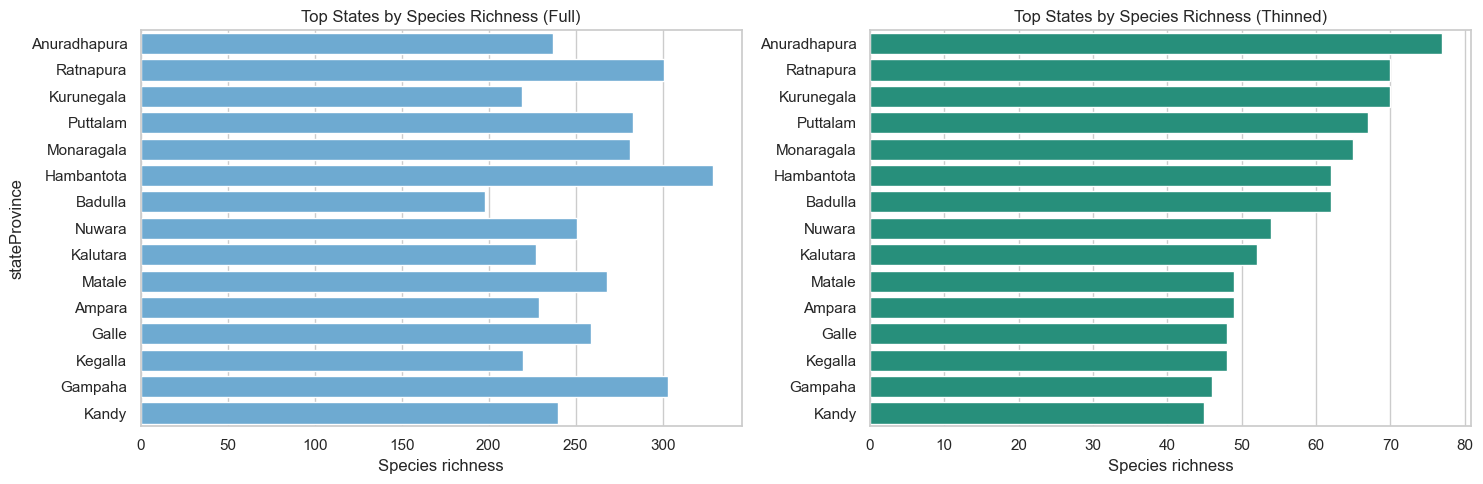

In [6]:
top_states = state_metrics.sort_values("species_richness_thin", ascending=False).head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_states, y="stateProvince", x="species_richness_full", ax=axes[0], color="#5dade2")
axes[0].set_title("Top States by Species Richness (Full)")
axes[0].set_xlabel("Species richness")
axes[0].set_ylabel("stateProvince")

sns.barplot(data=top_states, y="stateProvince", x="species_richness_thin", ax=axes[1], color="#16a085")
axes[1].set_title("Top States by Species Richness (Thinned)")
axes[1].set_xlabel("Species richness")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

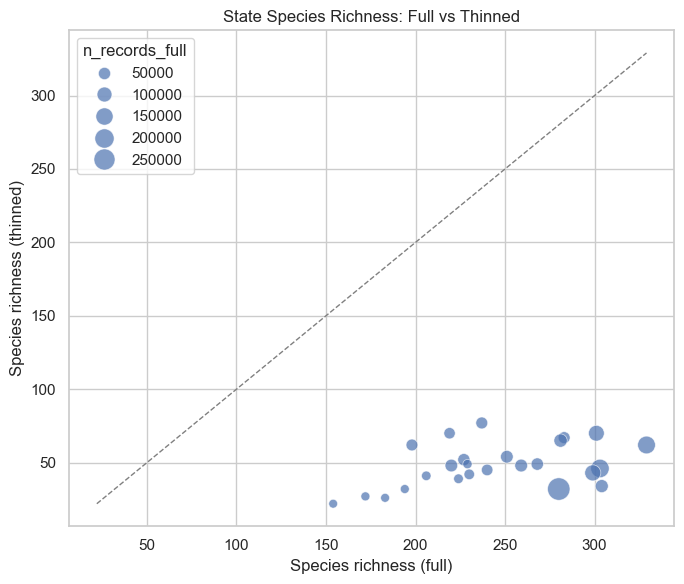

In [7]:
plt.figure(figsize=(7, 6))
plot_df = state_metrics[(state_metrics["species_richness_full"] > 0) & (state_metrics["species_richness_thin"] > 0)].copy()

sns.scatterplot(
    data=plot_df,
    x="species_richness_full",
    y="species_richness_thin",
    size="n_records_full",
    sizes=(40, 260),
    alpha=0.7,
)

min_v = min(plot_df["species_richness_full"].min(), plot_df["species_richness_thin"].min())
max_v = max(plot_df["species_richness_full"].max(), plot_df["species_richness_thin"].max())
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1)

plt.title("State Species Richness: Full vs Thinned")
plt.xlabel("Species richness (full)")
plt.ylabel("Species richness (thinned)")
plt.tight_layout()
plt.show()

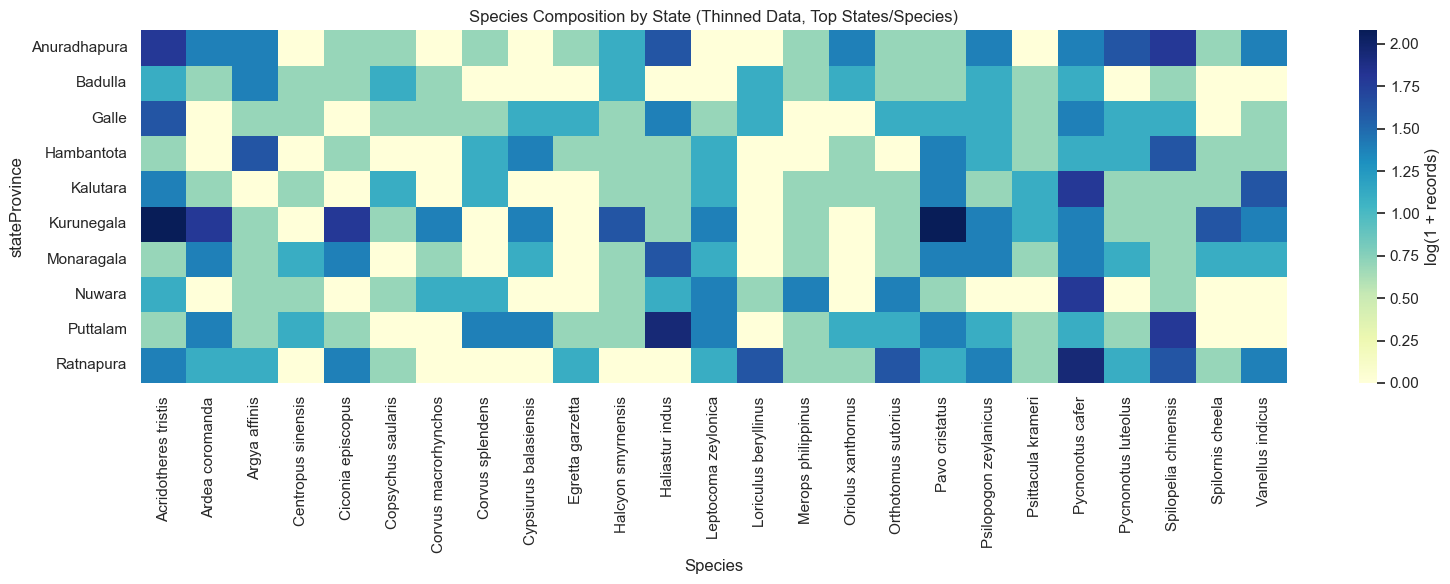

In [8]:
top_states_for_heatmap = state_metrics.sort_values("n_records_thin", ascending=False).head(10)["stateProvince"].tolist()
top_species_global = (
    state_species_counts_thin.groupby("verbatimScientificName")["n_records"].sum().sort_values(ascending=False).head(25).index.tolist()
)

heat_df = state_species_counts_thin[
    state_species_counts_thin["stateProvince"].isin(top_states_for_heatmap)
    & state_species_counts_thin["verbatimScientificName"].isin(top_species_global)
].copy()

matrix = heat_df.pivot_table(
    index="stateProvince",
    columns="verbatimScientificName",
    values="n_records",
    aggfunc="sum",
    fill_value=0,
)

plt.figure(figsize=(16, 6))
sns.heatmap(np.log1p(matrix), cmap="YlGnBu", cbar_kws={"label": "log(1 + records)"})
plt.title("Species Composition by State (Thinned Data, Top States/Species)")
plt.xlabel("Species")
plt.ylabel("stateProvince")
plt.tight_layout()
plt.show()

## 7. Export Tables for Reporting

In [9]:
out_dir = Path("images")
out_dir.mkdir(parents=True, exist_ok=True)

state_metrics.to_csv(out_dir / "state_species_metrics_full_vs_thinned.csv", index=False)
top_species_per_state.to_csv(out_dir / "state_top5_species_thinned.csv", index=False)

print("Saved:")
print(f"- {out_dir / 'state_species_metrics_full_vs_thinned.csv'}")
print(f"- {out_dir / 'state_top5_species_thinned.csv'}")

Saved:
- images\state_species_metrics_full_vs_thinned.csv
- images\state_top5_species_thinned.csv
